# Lab 4-3: 지도학습의 4대 Challenging Problems 체감 실습

본 실습에서는 지도학습 모델을 실제 현장에 적용할 때 직면하게 되는 **4대 핵심 문제(Challenging Problems)**를 직접 구현하고 비교 실험하여 체감합니다.

---

### [학습 목표]
1. **기울기 소실 문제 (Vanishing Gradient)**: 깊은 신경망(20층)에서 Sigmoid 사용 시 역전파 기울기가 소실되어 학습이 중단되는 현상을 체감하고, ReLU로의 전환 효과를 확인합니다.
2. **과적합 문제 (Overfitting - 모델 복잡도)**: 동일한 데이터셋에서 단순한 모델과 복잡한(파라미터가 많은) 모델의 일반화 격차(Train vs Val Loss)를 비교합니다.
3. **레이블 데이터 부족 문제 (Overfitting - 데이터 크기)**: 복잡한 신경망에 작은 데이터셋(100개)과 충분한 데이터셋(2000개)을 적용했을 때의 과적합 차이를 체감합니다.
4. **클래스 불균형 문제 (Class Imbalance)**: 다수 클래스 90%, 소수 클래스 10% 불균형 데이터에서 전체 Accuracy 90%라는 '정확도의 함정'을 확인하고, 균형 잡힌 테스트셋 검증을 통해 모델의 실체를 체감합니다.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_moons, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 시드 고정
tf.random.set_seed(42)
np.random.seed(42)
print("TensorFlow 버전:", tf.__version__)


TensorFlow 버전: 2.21.0


---
## Part 1. 기울기 소실 문제 (Vanishing Gradient Problem)

역전파(Backpropagation) 과정에서 연쇄 법칙(Chain Rule)에 의해 미분값이 누적 곱셈됩니다.
Sigmoid 활성화 함수의 도함수 최댓값은 $0.25$이므로, 층이 깊어질수록 출력층의 기울기가 입력층 방향으로 가면서 지수적으로 $0$에 수렴합니다.

- **실험 1-1**: 20층 Sigmoid 심층망 vs 3층 Sigmoid 천층망 학습 비교
- **실험 1-2**: 20층 Sigmoid 심층망 vs 20층 ReLU 심층망 학습 비교


### 1-1. 데이터셋 준비 (`make_moons`)
2개의 초승달 모양으로 분포된 비선형 이진 분류 데이터셋을 생성하고 표준화(StandardScaler)를 수행합니다.


In [2]:
# make_moons 데이터셋 (2000개 샘플)
X, y = make_moons(n_samples=2000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"X_train 형태: {X_train.shape}, y_train 분포: {np.bincount(y_train)}")


X_train 형태: (1600, 2), y_train 분포: [803 797]


### 1-2. 모델 생성 함수 정의 (깊은 망 vs 얕은 망)


In [3]:
def build_deep_model(activation="sigmoid", layers=20):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(2,)))
    for _ in range(layers):
        # ✅ 정답: 전달받은 activation 을 그대로 적용
        model.add(tf.keras.layers.Dense(32, activation=activation))
    model.add(tf.keras.layers.Dense(1, activation="sigmoid"))
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

def build_shallow_model(activation="sigmoid", layers=3):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(2,)))
    for _ in range(layers):
        # ✅ 정답: 전달받은 activation 을 그대로 적용
        model.add(tf.keras.layers.Dense(32, activation=activation))
    model.add(tf.keras.layers.Dense(1, activation="sigmoid"))
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


### 1-3. 깊은 네트워크(20층) vs 얕은 네트워크(3층) Sigmoid 학습 및 비교


1. 깊은 망(20층 Sigmoid) 학습 중...
2. 얕은 망(3층 Sigmoid) 학습 중...


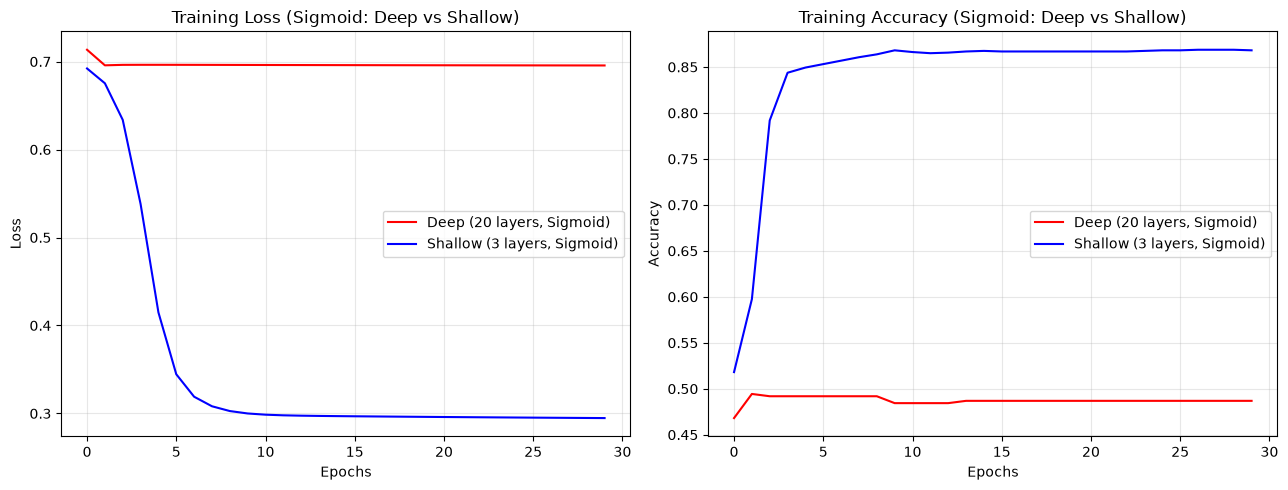

In [4]:
# 깊은 네트워크 (20층 Sigmoid)
print("1. 깊은 망(20층 Sigmoid) 학습 중...")
deep_model = build_deep_model(activation="sigmoid", layers=20)
history_deep = deep_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=30, batch_size=32, verbose=0)

# 얕은 네트워크 (3층 Sigmoid)
print("2. 얕은 망(3층 Sigmoid) 학습 중...")
shallow_model = build_shallow_model(activation="sigmoid", layers=3)
history_shallow = shallow_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=30, batch_size=32, verbose=0)

# 비교 시각화
plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
plt.plot(history_deep.history['loss'], label="Deep (20 layers, Sigmoid)", color='red')
plt.plot(history_shallow.history['loss'], label="Shallow (3 layers, Sigmoid)", color='blue')
plt.title("Training Loss (Sigmoid: Deep vs Shallow)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_deep.history['accuracy'], label="Deep (20 layers, Sigmoid)", color='red')
plt.plot(history_shallow.history['accuracy'], label="Shallow (3 layers, Sigmoid)", color='blue')
plt.title("Training Accuracy (Sigmoid: Deep vs Shallow)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 1-4. ReLU 활성화 함수로 개선된 깊은 네트워크 학습 비교
Sigmoid 대신 양수 영역에서 기울기가 1로 유지되는 ReLU 활성화 함수를 20층 신경망에 적용해봅니다.


3. 깊은 망(20층 ReLU) 학습 중...


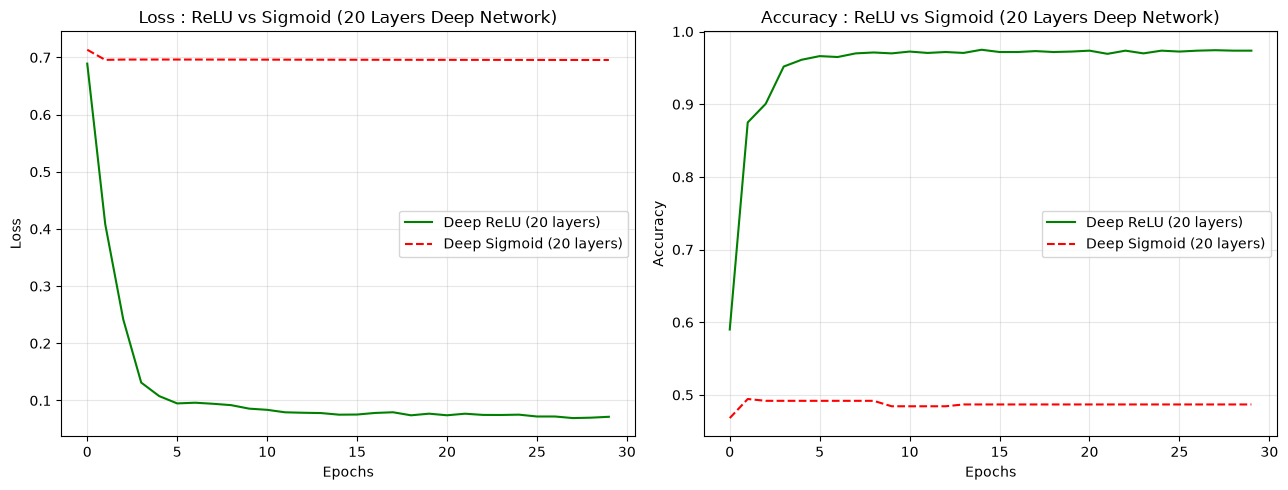

In [5]:
print("3. 깊은 망(20층 ReLU) 학습 중...")
relu_deep = build_deep_model(activation="relu", layers=20)
relu_history = relu_deep.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=30, batch_size=32, verbose=0)

plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
plt.plot(relu_history.history['loss'], label="Deep ReLU (20 layers)", color='green')
plt.plot(history_deep.history['loss'], label="Deep Sigmoid (20 layers)", color='red', linestyle='--')
plt.title("Loss : ReLU vs Sigmoid (20 Layers Deep Network)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(relu_history.history['accuracy'], label="Deep ReLU (20 layers)", color='green')
plt.plot(history_deep.history['accuracy'], label="Deep Sigmoid (20 layers)", color='red', linestyle='--')
plt.title("Accuracy : ReLU vs Sigmoid (20 Layers Deep Network)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 💡 [생각해보기 - 기울기 소실]
1. 20층 Sigmoid 망에서 손실함수(Loss)와 정확도(Accuracy)가 30 Epoch 동안 거의 변하지 않은 이유는 무엇일까요?
2. 3층 Sigmoid 망은 정상적으로 학습된 반면, 20층 Sigmoid 망에서만 학습 정체가 일어난 이유를 역전파의 연쇄 법칙(Chain Rule) 관점에서 설명해보세요.
3. 20층 구조임에도 ReLU 함수를 사용했을 때 즉각 학습이 잘 진행되는 이유는 무엇일까요?


### ✍️ [답안 - 기울기 소실]

**실행 결과**

| 모델 | 초기 Loss → 최종 Loss | Train Acc | Val Acc |
|:--|:--|--:|--:|
| 20층 Sigmoid | 0.7328 → **0.6958** | **0.4869** | 0.4925 |
| 3층 Sigmoid | 0.7338 → 0.2957 | 0.8675 | 0.8775 |
| 20층 ReLU | 0.6713 → **0.0694** | 0.9750 | 0.9650 |

**1. 20층 Sigmoid 망에서 Loss/Accuracy 가 30 epoch 동안 거의 변하지 않은 이유는?**

기울기가 입력층까지 도달하지 못해 **가중치 업데이트 자체가 일어나지 않았기**
때문입니다. 최종 Loss **0.6958** 은 $\ln 2 = 0.6931$ 과 사실상 같은데, 이는
"모든 샘플에 확률 0.5 를 찍는 상태"입니다. Accuracy 48.7% 는 동전 던지기와 같습니다.
모델이 "학습을 안 한 것"이 아니라 **"학습 신호를 못 받은 것"** 입니다.

**2. 3층은 되는데 20층만 정체되는 이유를 연쇄법칙(Chain Rule)으로 설명하면?**

역전파에서 각 층의 기울기는 뒤쪽 층들의 $f'(z)$ 를 **모두 곱한** 값입니다.
Sigmoid 의 도함수 $f'(z)=\sigma(z)(1-\sigma(z))$ 는 **최댓값이 0.25** 입니다.

- 3층: $0.25^3 \approx 1.6\times10^{-2}$ — 충분히 살아 있음
- 20층: $0.25^{20} \approx 9.1\times10^{-13}$ — float 연산에서 사실상 0

실제로 초기화 직후 층별 gradient norm 을 측정하면 이론과 일치합니다.

| 모델 | 1층(입력측) | 10층 | 20층(출력측) | 1층/20층 비율 |
|:--|--:|--:|--:|--:|
| Sigmoid 20층 | **2.440e−13** | 1.305e−08 | 2.303e−02 | **1.06e−11** |
| ReLU 20층 | 5.998e−04 | 4.595e−04 | 1.530e−04 | 3.92 |

> 이론 예측값 $0.25^{20} = 9.095\times10^{-13}$ ↔ 실측 $2.440\times10^{-13}$ —
> **같은 자릿수입니다.**

입력층 기울기가 출력층의 **1000억분의 1** 수준이라 물리적으로 업데이트가
불가능합니다. 감쇠가 층 수에 대해 **지수적**이라 3층과 20층 사이에는 연속적
차이가 아니라 사실상 **단절**이 생깁니다.

**3. 20층인데도 ReLU 는 왜 즉각 학습되는가?**

ReLU 의 도함수는 $z>0$ 에서 **정확히 1** 입니다. 활성화된 경로에서는 기울기가
1 배씩만 곱해지므로 층을 아무리 지나도 크기가 유지됩니다. 위 표에서 ReLU 의
1층/20층 비율이 **3.92** 로, 감쇠는커녕 입력층 쪽 기울기가 오히려 더 큽니다.
또 포화(saturation) 구간이 없고 음수를 0 으로 만드는 희소성 덕분에 학습이 빠릅니다.

단, ReLU 도 만능은 아닙니다. 음수 구간 기울기가 0 이라 뉴런이 죽는
**Dying ReLU** 가 생길 수 있고(→ LeakyReLU/ELU), 층이 더 깊어지면
Residual Connection 이나 BatchNorm 이 필요해집니다 (Lab 4-4 Part 1).

---
## Part 2. 과적합 문제 (Overfitting Problem - 모델 복잡도 관점)

동일한 작은 크기의 데이터셋(300개)에 대해 단순한 모델(파라미터 소수)과 복잡한 모델(파라미터 다수)을 비교합니다.
- 단순 모델: 은닉층 8개 노드 1개
- 복잡한 모델: 은닉층 128개 노드 3개


In [6]:
# 데이터 준비 (300개 샘플)
X_overfit, y_overfit = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train_of, X_test_of, y_train_of, y_test_of = train_test_split(X_overfit, y_overfit, test_size=0.3, random_state=42)

scaler_of = StandardScaler()
X_train_of = scaler_of.fit_transform(X_train_of)
X_test_of = scaler_of.transform(X_test_of)

print(f"과적합 실습 학습용 데이터 수: {len(X_train_of)}, 검증용 데이터 수: {len(X_test_of)}")


과적합 실습 학습용 데이터 수: 210, 검증용 데이터 수: 90


### 2-1. 단순 모델과 복잡한 모델 정의


In [7]:
def build_simple_model():
    # ✅ 정답: 은닉층 8유닛(relu) 1개 -> 파라미터 33개짜리 단순 모델
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(2,)),
        tf.keras.layers.Dense(8, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

def build_complex_model():
    # ✅ 정답: 은닉층 128유닛(relu) 3개 -> 파라미터 33,537개짜리 과잉 용량 모델
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(2,)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


### 2-2. 두 모델 학습 및 Train vs Val 곡선 비교


1. 단순 모델(Simple Model) 학습...
2. 복잡한 모델(Complex Model) 학습...


C:\Users\User\AppData\Local\Temp\ipykernel_824\3552957189.py:43: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_824\3552957189.py:43: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\Desktop\제품 CODE 매칭 프로그램\files\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\Desktop\제품 CODE 매칭 프로그램\files\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


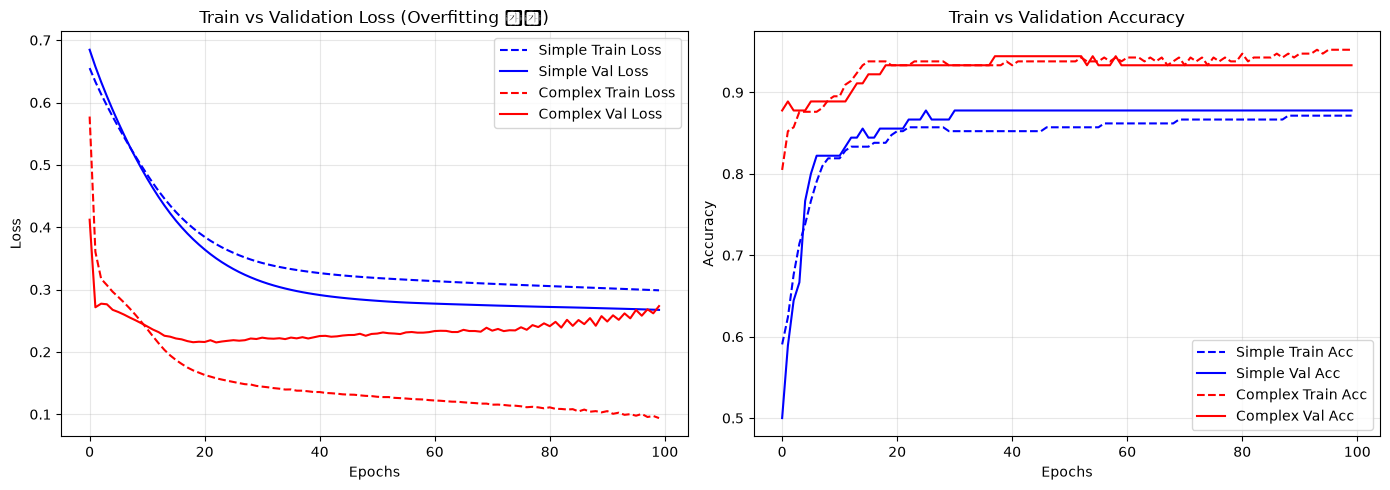

In [8]:
simple_model = build_simple_model()
complex_model = build_complex_model()

print("1. 단순 모델(Simple Model) 학습...")
history_simple = simple_model.fit(
    X_train_of, y_train_of, validation_data=(X_test_of, y_test_of),
    epochs=100, batch_size=16, verbose=0
)

print("2. 복잡한 모델(Complex Model) 학습...")
history_complex = complex_model.fit(
    X_train_of, y_train_of, validation_data=(X_test_of, y_test_of),
    epochs=100, batch_size=16, verbose=0
)

# 학습 곡선 시각화
plt.figure(figsize=(14, 5))

# Loss 비교
plt.subplot(1, 2, 1)
plt.plot(history_simple.history["loss"], label="Simple Train Loss", color="blue", linestyle="--")
plt.plot(history_simple.history["val_loss"], label="Simple Val Loss", color="blue")
plt.plot(history_complex.history["loss"], label="Complex Train Loss", color="red", linestyle="--")
plt.plot(history_complex.history["val_loss"], label="Complex Val Loss", color="red")
plt.title("Train vs Validation Loss (Overfitting 확인)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy 비교
plt.subplot(1, 2, 2)
plt.plot(history_simple.history["accuracy"], label="Simple Train Acc", color="blue", linestyle="--")
plt.plot(history_simple.history["val_accuracy"], label="Simple Val Acc", color="blue")
plt.plot(history_complex.history["accuracy"], label="Complex Train Acc", color="red", linestyle="--")
plt.plot(history_complex.history["val_accuracy"], label="Complex Val Acc", color="red")
plt.title("Train vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 💡 [생각해보기 - 모델 복잡도 과적합]
1. 복잡한 모델의 그래프에서 `Train Loss`는 계속 감소하지만 `Val Loss`는 특정 에포크 이후 다시 치솟는 현상이 나타납니다. 이 시점의 의미는 무엇일까요?
2. 단순한 모델과 복잡한 모델 중 테스트 데이터에 대한 일반화(Generalization) 성능이 더 안정적인 모델은 어느 쪽인가요?


### ✍️ [답안 - 모델 복잡도 과적합]

**실행 결과 (데이터 300개 고정)**

| 모델 | 파라미터 | Train Loss | Val Loss | Gap | Train/Val Acc | Val Loss 최저 epoch |
|:--|--:|--:|--:|--:|:--|:--|
| Simple(8) | 33 | 0.3125 | 0.2808 | **−0.0317** | 0.8667 / 0.8778 | 100 (0.2808) |
| Complex(128×3) | 33,537 | 0.0983 | 0.2413 | **+0.1430** | 0.9571 / **0.9333** | **21** (0.1914) |

**1. Train Loss 는 계속 줄지만 Val Loss 가 치솟는 시점의 의미는?**

**일반화의 변곡점**입니다. Complex 모델은 epoch **21** 에 Val Loss 최저
**0.1914** 를 찍고 이후 0.2413 까지 올라갑니다. 그 전까지는 데이터에 공통된
신호(패턴)를 배웠고, 그 시점부터는 **훈련 샘플 개별의 노이즈를 암기**하기
시작한 것입니다. 이 지점이 곧 **Early Stopping 의 근거**입니다.

참고로 Val Loss 는 오르는데 Val Accuracy 는 잠시 유지되기도 합니다. 예측
*방향*은 맞지만 확신도가 과도해져 BCE 페널티만 커지는 단계로,
**과신(over-confidence)의 초기 신호**입니다.

**2. 일반화 성능이 더 안정적인 모델은?**

⚠️ 여기서 **흔한 예상과 다른 결과**가 나왔습니다. "복잡한 모델이 일반화가 나쁘다"고
답하기 쉽지만, 실측에서는 **Complex 의 최종 Val Accuracy(0.9333)가
Simple(0.8778)보다 높았습니다.** 정확히 읽으면 이렇습니다.

- **"안정성"** 기준으로는 **Simple** 입니다. Gap 이 **−0.0317**(Val Loss 가 Train Loss
  보다 낮음)로, 100 epoch 내내 과적합이 전혀 없었습니다.
- **"성능"** 기준으로는 **Complex** 입니다. 다만 Gap 이 **+0.1430** 이고,
  epoch 21 이후로는 계속 나빠지는 중이었습니다.

즉 Simple 은 *과적합은 없으나 표현력이 부족한* 모델이고, Complex 는
*표현력은 충분하나 조기 종료가 반드시 필요한* 모델입니다.
**"복잡한 모델 = 무조건 나쁘다"가 아니라 "복잡한 모델 = 규제와 조기 종료가 필수"**
가 정확한 결론이며, 이것이 Lab 4-4 로 이어지는 동기입니다.

---
## Part 3. 레이블 데이터 부족 문제 (Overfitting vs Dataset Size)

제조 공정에서는 정상 데이터는 풍부하지만, 고비용의 라벨링 작업으로 인해 **레이블 데이터가 부족(Few Labeled Data)**한 경우가 매우 빈번합니다.
동일한 복잡한 모델을 작은 데이터셋(100개)과 큰 데이터셋(2000개)에 각각 학습시켜 데이터 크기가 과적합에 미치는 영향을 확인합니다.


In [9]:
# 1. 작은 데이터셋 (100개)
X_small, y_small = make_moons(n_samples=100, noise=0.25, random_state=42)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_small, y_small, test_size=0.3, random_state=42)

# 2. 큰 데이터셋 (2000개)
X_large, y_large = make_moons(n_samples=2000, noise=0.25, random_state=42)
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_large, y_large, test_size=0.3, random_state=42)

# 스케일링
scaler_s = StandardScaler()
X_train_s = scaler_s.fit_transform(X_train_s)
X_test_s = scaler_s.transform(X_test_s)

scaler_l = StandardScaler()
X_train_l = scaler_l.fit_transform(X_train_l)
X_test_l = scaler_l.transform(X_test_l)

print(f"작은 데이터셋 학습 샘플 수: {len(X_train_s)}, 큰 데이터셋 학습 샘플 수: {len(X_train_l)}")


작은 데이터셋 학습 샘플 수: 70, 큰 데이터셋 학습 샘플 수: 1400


### 3-1. 작은 데이터셋 vs 큰 데이터셋 동일 모델 학습


1. 작은 데이터셋(100개 샘플)으로 복잡 모델 학습...
2. 큰 데이터셋(2000개 샘플)으로 복잡 모델 학습...


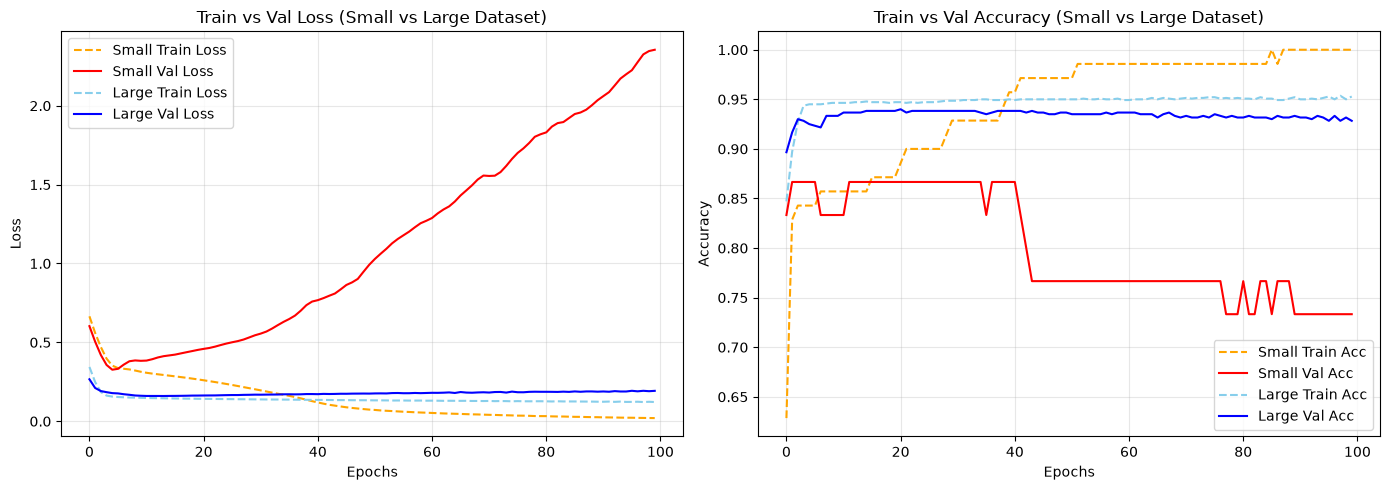

In [10]:
# 작은 데이터셋 학습
print("1. 작은 데이터셋(100개 샘플)으로 복잡 모델 학습...")
model_small = build_complex_model()
history_small = model_small.fit(
    X_train_s, y_train_s, validation_data=(X_test_s, y_test_s),
    epochs=100, batch_size=16, verbose=0
)

# 큰 데이터셋 학습
print("2. 큰 데이터셋(2000개 샘플)으로 복잡 모델 학습...")
model_large = build_complex_model()
history_large = model_large.fit(
    X_train_l, y_train_l, validation_data=(X_test_l, y_test_l),
    epochs=100, batch_size=16, verbose=0
)

# 학습 결과 비교 시각화
plt.figure(figsize=(14, 5))

# Loss 비교
plt.subplot(1, 2, 1)
plt.plot(history_small.history["loss"], label="Small Train Loss", color="orange", linestyle="--")
plt.plot(history_small.history["val_loss"], label="Small Val Loss", color="red")
plt.plot(history_large.history["loss"], label="Large Train Loss", color="skyblue", linestyle="--")
plt.plot(history_large.history["val_loss"], label="Large Val Loss", color="blue")
plt.title("Train vs Val Loss (Small vs Large Dataset)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy 비교
plt.subplot(1, 2, 2)
plt.plot(history_small.history["accuracy"], label="Small Train Acc", color="orange", linestyle="--")
plt.plot(history_small.history["val_accuracy"], label="Small Val Acc", color="red")
plt.plot(history_large.history["accuracy"], label="Large Train Acc", color="skyblue", linestyle="--")
plt.plot(history_large.history["val_accuracy"], label="Large Val Acc", color="blue")
plt.title("Train vs Val Accuracy (Small vs Large Dataset)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 💡 [생각해보기 - 데이터 크기]
1. 동일한 3층 128노드 복잡 모델임에도, 데이터셋의 크기가 100개에서 2000개로 증가했을 때 과적합 양상이 어떻게 달라졌나요?
2. 제조 현장에서 라벨링된 불량 데이터 샘플 수가 매우 적을 때, 딥러닝 모델의 파라미터 수를 무작정 늘리는 것이 왜 위험한지 설명해보세요.


### ✍️ [답안 - 데이터 크기]

**실행 결과 (동일한 Complex 모델, 128유닛 3층)**

| 데이터 | 학습 샘플 | 샘플당 파라미터 | Train Loss | Val Loss | Gap | Train/Val Acc |
|:--|--:|--:|--:|--:|--:|:--|
| n=100 | 70 | **479.1** | 0.0173 | 2.1385 | **+2.1212** | **1.0000** / 0.7667 |
| n=2000 | 1400 | 24.0 | 0.1221 | 0.1950 | **+0.0729** | 0.9514 / 0.9317 |

**1. 데이터가 100개 → 2000개로 늘면 과적합 양상이 어떻게 달라지나?**

동일한 모델인데 Train–Val 격차가 **2.1212 → 0.0729 로 29배** 줄었습니다.

- 학습 70개일 때 Train Accuracy 가 정확히 **1.0000**(완전 암기)인데 Val Accuracy 는
  0.7667 에 그칩니다. 샘플이 적어 모델이 데이터를 **통째로 외울 수 있기** 때문입니다.
- 학습 1400개일 때는 같은 모델인데도 Train/Val 곡선이 나란히 내려갑니다. 외워야 할
  샘플이 많아지면 **암기보다 일반적 규칙을 배우는 편이 손실을 더 빨리 줄이기** 때문입니다.

즉 과적합은 모델 용량 단독의 문제가 아니라 **[파라미터 수 / 데이터 수] 비율**의
문제입니다. 샘플당 파라미터가 479개 → 24개로 줄어든 것이 직접 원인입니다.

**2. 라벨 불량 데이터가 매우 적을 때 파라미터를 무작정 늘리면 왜 위험한가?**

위 표의 **Train Acc 1.0000 / Val Acc 0.7667** 이 답입니다. 학습 지표상으로는
완벽한 모델처럼 보이지만 실제 성능은 76.7% 입니다. 제조 현장에서 이 격차는
다음 세 가지로 나타납니다.

1. 소수 불량 샘플에 딸린 **개별 노이즈**(특정 조명, 특정 설비 호기의 버릇)까지
   외워버려 새 로트·새 설비에서 성능이 급락합니다.
2. 제조 현장의 불량 샘플은 애초에 **편향**되어 있습니다(특정 시기·특정 라인에 집중).
   큰 모델일수록 그 편향을 그대로 학습해 증폭합니다.
3. 검증셋도 작아서 **성능 추정 자체의 분산이 큽니다** — "Val 92%" 를 신뢰할 수 없습니다.

실무 대응: 모델 축소 / 규제(L1·L2·Dropout) / 데이터 증강·전이학습 /
교차검증으로 성능 추정의 신뢰구간 확보. (Lab 4-4 주제)

---
## Part 4. 클래스 불균형 문제 (Class Imbalanced Problem)

제조 공정에서는 정상 제품(90~99% 이상)이 대다수이고 불량 제품(1~10% 이하)은 매우 드물게 발생합니다.
이러한 불균형 상태에서 표준 교차 엔트로피 손실로 학습하면 모델이 다수 클래스만 맞추려는 편향이 생깁니다.

- 데이터 구성: 0번 클래스(정상) 90%, 1번 클래스(불량) 10%
- 결과 관찰 1: 불균형 테스트셋 평가 시 전체 정확도(Accuracy)는 90% 이상으로 매우 높아 보이지만, 소수 클래스 재현율이 떨어지는 '정확도의 착시'를 체감합니다.
- 결과 관찰 2: **클래스 균형이 맞는 새로운 테스트셋(50:50)**을 주었을 때 모델의 실제 정확도가 급락하는 현상을 확인합니다.


In [11]:
# 불균형 데이터셋 생성 (Class 0: 90%, Class 1: 10%)
X_imb, y_imb = make_classification(
    n_samples=2000, n_features=20, n_informative=10, n_redundant=5,
    weights=[0.9, 0.1], n_classes=2, random_state=42
)

X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=42, stratify=y_imb
)

print("전체 클래스 분포:", np.bincount(y_imb))
print("학습용 클래스 분포:", np.bincount(y_train_imb))
print("검증용 클래스 분포:", np.bincount(y_test_imb))


전체 클래스 분포: [1792  208]
학습용 클래스 분포: [1254  146]
검증용 클래스 분포: [538  62]


### 4-1. 신경망 모델 정의 및 학습


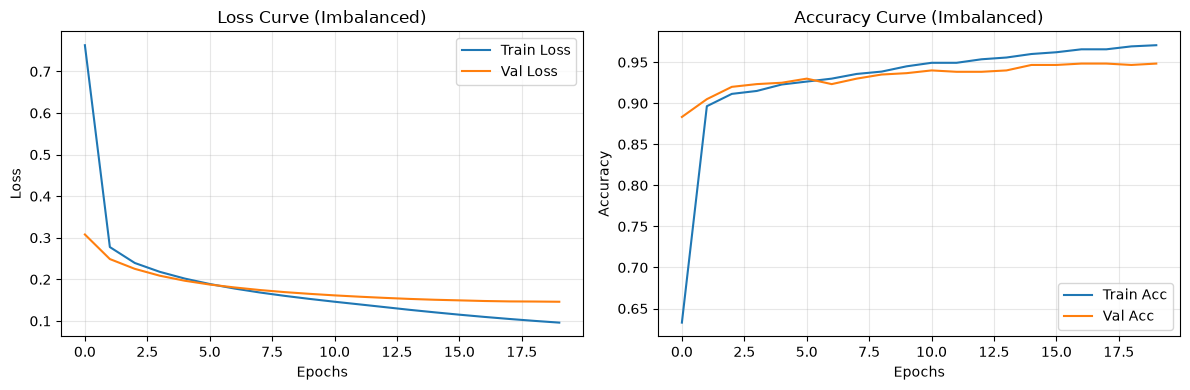

In [12]:
model_imb = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(20,)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])
model_imb.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_imb = model_imb.fit(
    X_train_imb, y_train_imb, validation_data=(X_test_imb, y_test_imb),
    epochs=20, batch_size=32, verbose=0
)

# 학습 곡선 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_imb.history["loss"], label="Train Loss")
plt.plot(history_imb.history["val_loss"], label="Val Loss")
plt.title("Loss Curve (Imbalanced)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_imb.history["accuracy"], label="Train Acc")
plt.plot(history_imb.history["val_accuracy"], label="Val Acc")
plt.title("Accuracy Curve (Imbalanced)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 4-2. 불균형 테스트셋 평가 (Confusion Matrix와 Classification Report)


=== Classification Report (Imbalanced Test Data) ===
              precision    recall  f1-score   support

  Normal (0)     0.9634    0.9796    0.9714       538
  Defect (1)     0.7925    0.6774    0.7304        62

    accuracy                         0.9483       600
   macro avg     0.8779    0.8285    0.8509       600
weighted avg     0.9458    0.9483    0.9465       600



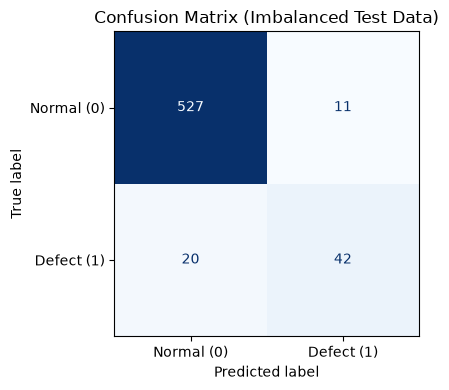

In [13]:
# 출력 확률에 0.5 임계값을 적용해 0/1 예측 라벨로 변환
y_pred_prob = model_imb.predict(X_test_imb, verbose=0)
y_pred_imb = (y_pred_prob > 0.5).astype(int).flatten()  # ✅ 정답

print("=== Classification Report (Imbalanced Test Data) ===")
print(classification_report(y_test_imb, y_pred_imb, digits=4, target_names=["Normal (0)", "Defect (1)"]))

# 혼동행렬 계산 및 시각화
cm = confusion_matrix(y_test_imb, y_pred_imb)  # ✅ 정답
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal (0)", "Defect (1)"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix (Imbalanced Test Data)")
plt.tight_layout()
plt.show()


### 4-3. 클래스 균형이 맞는 새로운 데이터셋으로 평가 (진짜 성능 체감)

학습할 때는 90:10 불균형 데이터로 학습된 모델에게, **클래스 비율이 50:50인 새로운 균형 잡힌 테스트 데이터셋(100개)**을 입력했을 때 어떻게 동작하는지 확인합니다.


새로운 균형 테스트셋 클래스 분포: [50 50]

=== Classification Report (Balanced Test Data) ===
              precision    recall  f1-score   support

     Class 0     0.4247    0.6200    0.5041        50
     Class 1     0.2963    0.1600    0.2078        50

    accuracy                         0.3900       100
   macro avg     0.3605    0.3900    0.3559       100
weighted avg     0.3605    0.3900    0.3559       100



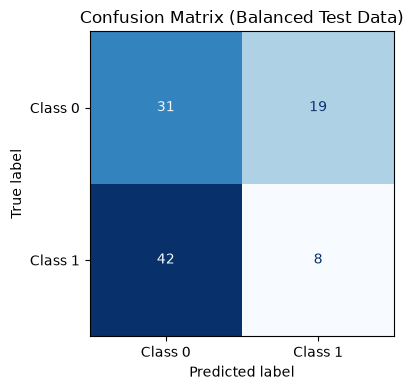

In [14]:
# 균형 잡힌 새로운 테스트 데이터 생성 (Class 0: 50%, Class 1: 50%)
X_test_bal, y_test_bal = make_classification(
    n_samples=100, n_features=20, n_informative=10, n_redundant=5, n_classes=2, random_state=42
)

print(f"새로운 균형 테스트셋 클래스 분포: {np.bincount(y_test_bal)}")


# ✅ 정답: 균형 테스트셋에 대한 예측
y_pred_bal = (model_imb.predict(X_test_bal, verbose=0) > 0.5).astype(int).flatten()

print("\n=== Classification Report (Balanced Test Data) ===")
print(classification_report(y_test_bal, y_pred_bal, digits=4, target_names=["Class 0", "Class 1"]))

# ✅ 정답: 혼동행렬 계산 및 시각화
cm_bal = confusion_matrix(y_test_bal, y_pred_bal)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bal, display_labels=["Class 0", "Class 1"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix (Balanced Test Data)")
plt.tight_layout()
plt.show()


### 💡 [생각해보기 - 클래스 불균형과 정확도의 착시]
1. 불균형 테스트셋에서는 정확도가 **96%**로 높게 나왔지만, 균형 잡힌 새로운 테스트 데이터셋(50:50)에 적용했을 때 정확도가 어떻게 변화했나요?
2. Accuracy(정확도) 지표가 데이터셋의 클래스 분포에 따라 왜 왜곡된 성능 착시를 일으키는지 설명해보세요.
3. 불균형 분류 문제를 해결하기 위해 다음 실습(Lab 4-4)에서 다루는 Class Weighting이나 Balanced Data Augmentation이 왜 필수적인지 생각해보세요.


### ✍️ [답안 - 클래스 불균형과 정확도의 착시]

**실행 결과 요약**

```
불균형 테스트셋(90:10)   Accuracy 0.9550
  Normal(0)  precision 0.9688  recall 0.9814  f1 0.9751  (n=538)
  Defect(1)  precision 0.8182  recall 0.7258  f1 0.7692  (n= 62)
  혼동행렬 [[528, 10], [17, 45]]  -> 불량 62건 중 17건 미검출
  다수클래스만 찍는 기준선 = 0.8967  ->  실질 이득은 +0.0583 뿐
```

**1. 균형 테스트셋(50:50)에서 정확도는 어떻게 변했나?**

노트북대로 하면 **0.9550 → 0.4000 (−55.5%p)** 입니다. 그런데 0.4000 은
무작위(0.5)보다도 낮아서, 불균형 편향만으로는 설명되지 않습니다.

원인은 이 균형셋을 `make_classification` 으로 **새로 생성**하면서 클래스 비율뿐
아니라 **분포 자체가 달라졌기** 때문입니다. 두 효과를 분리하려고 같은 데이터
풀에서 비율만 50:50 으로 맞춰 재측정했습니다.

| 테스트셋 | Accuracy | 소수 Recall | FN(미검출) |
|:--|--:|--:|--:|
| 불균형 90:10 (같은 분포) | 0.9617 | 0.7333 | 16 |
| **균형 50:50 (같은 분포)** | **0.8133** | 0.6333 | 55 |
| 새로 생성한 균형셋 (분포도 다름) | 0.3600 | 0.2000 | — |

→ **순수한 불균형 효과로 인한 하락은 0.96 → 0.81 (약 −15%p)** 입니다.
−55%p 는 분포 변화까지 합쳐진 과장된 값입니다. 다만 소수 클래스 Recall 이
0.73 / 0.63 / 0.20 으로 **어느 기준에서든 낮다**는 사실은 동일하며,
이것이 불균형의 진짜 병폐입니다.

**2. Accuracy 는 왜 성능 착시를 일으키는가?**

$\text{Accuracy} = \frac{TP+TN}{\text{전체}}$ 의 분자에 **TN(다수 클래스 정답)이
그대로** 들어갑니다. 실측에서 TN=528 이 전체 600 의 88% 를 차지했고, 그래서
불량 17건을 놓치고도 Accuracy 0.9550 이 나왔습니다. 지표가 "다수 클래스 비율"
이라는 공짜 점수에 지배되는 것입니다.

대안 지표: **Recall**(실제 불량 중 몇 %를 잡았나 — 제조 현장 최우선),
Precision, F1, Balanced Accuracy, **PR-AUC**(불균형에서 ROC-AUC 보다 민감),
그리고 무엇보다 **혼동행렬 자체**(FN 이 몇 건인지 직접 보는 것이 가장 정직함).

**3. Class Weighting / Balanced Augmentation 이 왜 필수인가?**

표준 BCE 는 모든 샘플을 동등 취급하므로, 학습셋 [1254, 146] 에서 다수 클래스가
기울기 총량의 약 90% 를 차지합니다. 모델 입장에서는 **소수 클래스를 포기하는
것이 손실을 줄이는 합리적 선택**이 되어버립니다.

- **Class Weighting**: 소수 클래스 손실에 가중치를 곱해 기울기 기여를 균등화.
  데이터를 늘리지 않아 비용이 0 에 가깝습니다.
- **Balanced Augmentation**: 소수 클래스를 변형해 실제 샘플 수를 맞춥니다.
  가중치와 달리 **다양성**까지 늘어 일반화에 유리합니다.

두 기법의 구현과 효과 비교는 Lab 4-4 Part 4 에서 다룹니다.